In [1]:
# !pip install numpy scikit-learn gurobipy

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler
import time
import warnings
warnings.filterwarnings("ignore")
from MIP import best_subset_full, discrete_first_order, best_subset_mio

# Data generation

In [4]:
def generate_data(n, p, k0, rho=0.5, SNR=3.0, seed=0):
    rng = np.random.default_rng(seed)
    # Macierz kowariancji AR(1)
    idx = np.arange(p)
    Sigma = rho ** np.abs(idx[:, None] - idx[None, :])
    L = np.linalg.cholesky(Sigma)
    X = rng.standard_normal((n, p)) @ L.T
    # Standaryzacja kolumn do ||X_j||_2 = 1 (wymóg paperu)
    X = X - X.mean(axis=0)
    X = X / np.linalg.norm(X, axis=0)
    # True beta: k0 niezerowych, equispaced indeksy, wartość 1
    beta0 = np.zeros(p)
    indices = np.round(np.linspace(0, p - 1, k0)).astype(int)
    beta0[indices] = 1.0
    # Szum dopasowany do SNR
    signal_var = np.var(X @ beta0)
    sigma2 = signal_var / SNR
    eps = rng.normal(0, np.sqrt(sigma2), n)
    y = X @ beta0 + eps
    return X, y, beta0

In [5]:
def prediction_error(X, beta_hat, beta0):
    """
    Prediction Error = ||X(beta_hat - beta0)||^2 / ||X*beta0||^2
    Równanie (5.2) z paperu.
    """
    num = np.sum((X @ beta_hat - X @ beta0) ** 2)
    den = np.sum((X @ beta0) ** 2)
    if den < 1e-10:
        return 0.0
    return num / den
def select_k_by_validation(X_train, y_train, X_val, y_val,
                            k_range, method="mio", time_limit=60):
    """
    Wybór optymalnego k przez held-out validation (Sekcja 5.2.3 paperu).
    """
    best_k = k_range[0]
    best_val_loss = np.inf
    for k in k_range:
        if method == "mio":
            result = best_subset_full(X_train, y_train, k,
                                      time_limit=time_limit, n_restarts=20)
            beta = result["beta_mio"]
            if beta is None:
                beta = result["beta_fo"]
        else:  # first_order
            beta, _ = discrete_first_order(X_train, y_train, k, n_restarts=20)
        val_loss = np.mean((y_val - X_val @ beta) ** 2)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_k = k
    return best_k

# Lasso & MIP

In [6]:
np.random.seed(42)
n, p, k0 = 500, 100, 10
rho_values = [0.5, 0.8, 0.9]
SNR = 3.0
n_repeats = 3        # paper używa 10; zmniejsz do 3 dla szybkości
k_range = list(range(max(1, k0 - 5), k0 + 6))
results = {rho: {"mio": [], "lasso": [], "fo": []} for rho in rho_values}
for rho in rho_values:
    print(f"\n=== rho = {rho} ===")
    for rep in range(n_repeats):
        X, y, beta0 = generate_data(n, p, k0, rho=rho, SNR=SNR, seed=rep)
        # Podział: train / validation / test (60/20/20)
        n_train = int(0.6 * n)
        n_val   = int(0.2 * n)
        X_train, y_train = X[:n_train], y[:n_train]
        X_val,   y_val   = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
        X_test,  y_test  = X[n_train+n_val:], y[n_train+n_val:]
        # --- MIO (z warm startem z Alg. 2) ---
        t0 = time.time()
        best_k_mio = select_k_by_validation(
            X_train, y_train, X_val, y_val,
            k_range, method="mio", time_limit=30
        )
        result = best_subset_full(X_train, y_train, best_k_mio,
                                  time_limit=60, n_restarts=30)
        beta_mio = result["beta_mio"] if result["beta_mio"] is not None else result["beta_fo"]
        pe_mio = prediction_error(X_test, beta_mio, beta0)
        nnz_mio = int(np.sum(np.abs(beta_mio) > 1e-6))
        gap_mio = result["mio_gap"]
        t_mio = time.time() - t0
        # --- Discrete first-order only (Alg. 2) ---
        t0 = time.time()
        best_k_fo = select_k_by_validation(
            X_train, y_train, X_val, y_val,
            k_range, method="first_order", time_limit=30
        )
        beta_fo, _ = discrete_first_order(X_train, y_train, best_k_fo, n_restarts=50)
        pe_fo = prediction_error(X_test, beta_fo, beta0)
        nnz_fo = int(np.sum(np.abs(beta_fo) > 1e-6))
        t_fo = time.time() - t0
        # --- Lasso (z LassoCV) ---
        t0 = time.time()
        lasso_cv = LassoCV(cv=5, max_iter=5000).fit(X_train, y_train)
        beta_lasso = lasso_cv.coef_
        pe_lasso = prediction_error(X_test, beta_lasso, beta0)
        nnz_lasso = int(np.sum(np.abs(beta_lasso) > 1e-6))
        t_lasso = time.time() - t0
        results[rho]["mio"].append({
            "pred_err": pe_mio, "nnz": nnz_mio,
            "gap": gap_mio, "time": t_mio, "k": best_k_mio
        })
        results[rho]["lasso"].append({
            "pred_err": pe_lasso, "nnz": nnz_lasso, "time": t_lasso
        })
        results[rho]["fo"].append({
            "pred_err": pe_fo, "nnz": nnz_fo, "time": t_fo, "k": best_k_fo
        })
        print(f"  rep={rep+1} | MIO: PE={pe_mio:.4f}, nnz={nnz_mio}, gap={gap_mio:.3f} "
              f"| FO: PE={pe_fo:.4f}, nnz={nnz_fo} "
              f"| Lasso: PE={pe_lasso:.4f}, nnz={nnz_lasso}")



=== rho = 0.5 ===
Restricted license - for non-production use only - expires 2027-11-29
  rep=1 | MIO: PE=0.0084, nnz=10, gap=0.000 | FO: PE=0.0084, nnz=10 | Lasso: PE=0.0467, nnz=25
  rep=2 | MIO: PE=0.0068, nnz=10, gap=0.000 | FO: PE=0.0066, nnz=10 | Lasso: PE=0.0308, nnz=25
  rep=3 | MIO: PE=0.0108, nnz=10, gap=0.000 | FO: PE=0.0110, nnz=10 | Lasso: PE=0.0783, nnz=37

=== rho = 0.8 ===
  rep=1 | MIO: PE=0.0115, nnz=10, gap=0.000 | FO: PE=0.0153, nnz=11 | Lasso: PE=0.0402, nnz=26
  rep=2 | MIO: PE=0.0213, nnz=13, gap=0.000 | FO: PE=0.0266, nnz=14 | Lasso: PE=0.0264, nnz=28
  rep=3 | MIO: PE=0.0102, nnz=10, gap=0.000 | FO: PE=0.0477, nnz=15 | Lasso: PE=0.0598, nnz=40

=== rho = 0.9 ===
  rep=1 | MIO: PE=0.0357, nnz=10, gap=0.069 | FO: PE=0.0382, nnz=14 | Lasso: PE=0.0341, nnz=28
  rep=2 | MIO: PE=0.0058, nnz=10, gap=0.039 | FO: PE=0.0583, nnz=15 | Lasso: PE=0.0260, nnz=31
  rep=3 | MIO: PE=0.0093, nnz=10, gap=0.111 | FO: PE=0.0575, nnz=13 | Lasso: PE=0.0526, nnz=40


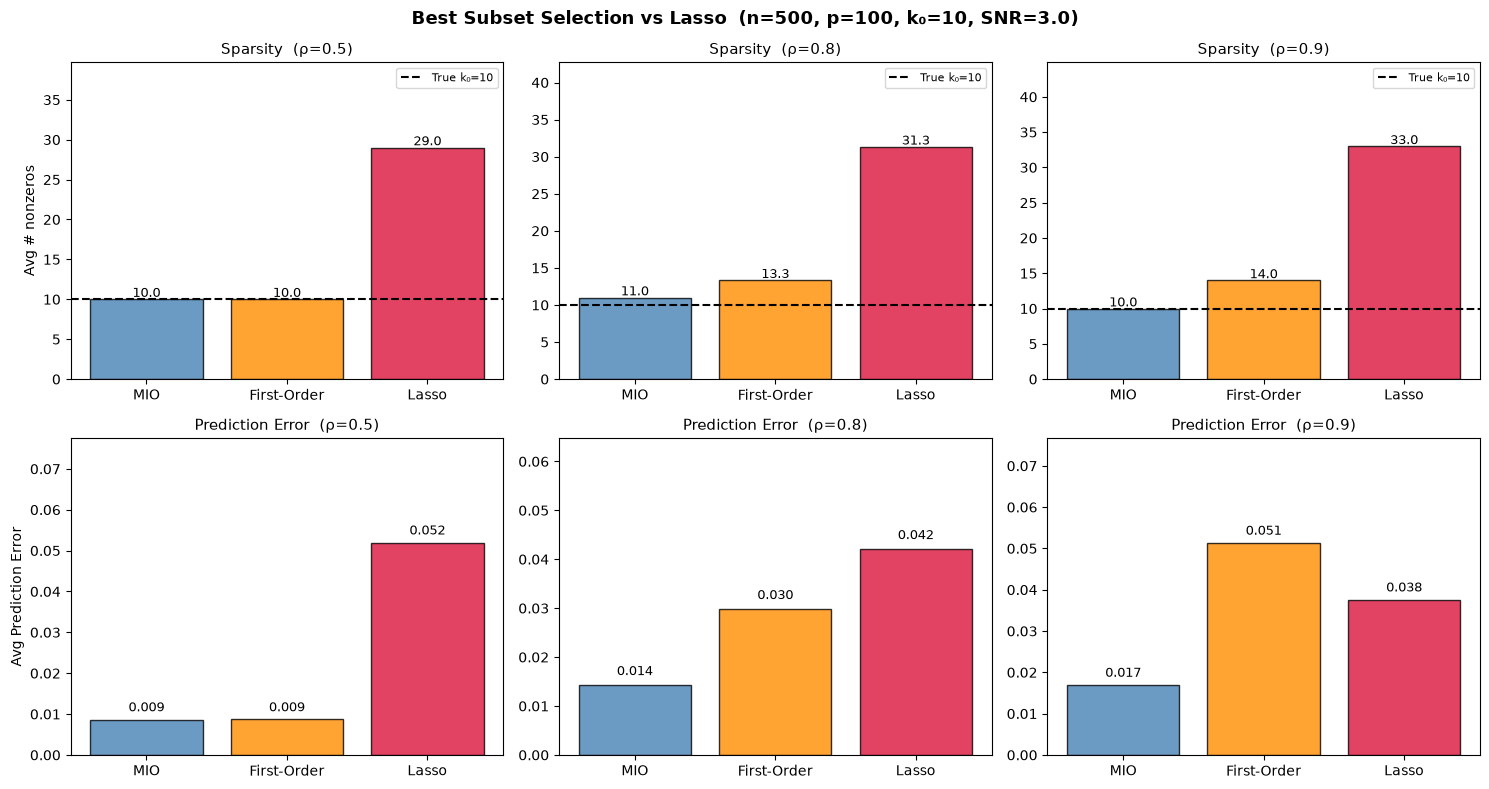

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f"Best Subset Selection vs Lasso  (n={n}, p={p}, k₀={k0}, SNR={SNR})",
             fontsize=13, fontweight="bold")
for col, rho in enumerate(rho_values):
    r = results[rho]
    mio_pe    = [d["pred_err"] for d in r["mio"]]
    lasso_pe  = [d["pred_err"] for d in r["lasso"]]
    fo_pe     = [d["pred_err"] for d in r["fo"]]
    mio_nnz   = [d["nnz"] for d in r["mio"]]
    lasso_nnz = [d["nnz"] for d in r["lasso"]]
    fo_nnz    = [d["nnz"] for d in r["fo"]]
    methods = ["MIO", "First-Order", "Lasso"]
    pe_vals  = [np.mean(mio_pe), np.mean(fo_pe), np.mean(lasso_pe)]
    nnz_vals = [np.mean(mio_nnz), np.mean(fo_nnz), np.mean(lasso_nnz)]
    colors   = ["steelblue", "darkorange", "crimson"]
    # Górny wiersz: sparsity (liczba niezerowych)
    ax_top = axes[0, col]
    bars = ax_top.bar(methods, nnz_vals, color=colors, alpha=0.8, edgecolor="black")
    ax_top.axhline(k0, color="black", linestyle="--", linewidth=1.5,
                   label=f"True k₀={k0}")
    ax_top.set_title(f"ρ = {rho}", fontsize=11)
    ax_top.set_ylabel("Avg # nonzeros" if col == 0 else "")
    ax_top.legend(fontsize=8)
    ax_top.set_ylim(0, max(nnz_vals) * 1.3 + 2)
    for bar, val in zip(bars, nnz_vals):
        ax_top.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                    f"{val:.1f}", ha="center", fontsize=9)
    # Dolny wiersz: prediction error
    ax_bot = axes[1, col]
    bars = ax_bot.bar(methods, pe_vals, color=colors, alpha=0.8, edgecolor="black")
    ax_bot.set_ylabel("Avg Prediction Error" if col == 0 else "")
    ax_bot.set_ylim(0, max(pe_vals) * 1.3 + 0.01)
    for bar, val in zip(bars, pe_vals):
        ax_bot.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                    f"{val:.3f}", ha="center", fontsize=9)
axes[0, 0].set_title(f"Sparsity  (ρ={rho_values[0]})", fontsize=11)
for col, rho in enumerate(rho_values):
    axes[0, col].set_title(f"Sparsity  (ρ={rho})", fontsize=11)
    axes[1, col].set_title(f"Prediction Error  (ρ={rho})", fontsize=11)
plt.tight_layout()
plt.savefig("figure4_replication.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
print("\n=== Ewolucja MIO gap ===")
X_demo, y_demo, beta0_demo = generate_data(500, 100, 10, rho=0.5, SNR=3.0, seed=99)
X_demo = X_demo - X_demo.mean(0)
X_demo = X_demo / np.linalg.norm(X_demo, axis=0)
k_vals_demo = [5, 10, 15]
gap_history = {}
for k_demo in k_vals_demo:
    # Warm start z Alg. 2
    beta_fo_demo, _ = discrete_first_order(X_demo, y_demo, k_demo, n_restarts=30)
    # MIO z verbose=True żeby zobaczyć postęp
    model_data = []
    class GapCallback:
        """Callback zbierający ewolucję gap."""
        def __init__(self):
            self.times = []
            self.gaps = []
            self.obj_vals = []
    # Uruchom MIO i zbierz gap po zakończeniu
    beta_m, z_m, gap_m, obj_m = best_subset_mio(
        X_demo, y_demo, k_demo,
        time_limit=120,
        beta_init=beta_fo_demo
    )
    gap_history[k_demo] = gap_m
    print(f"  k={k_demo}: final gap = {gap_m:.4f}, obj = {obj_m:.4f}, nnz = {int(np.sum(np.abs(beta_m)>1e-6))}")
print("\nMIO gap (certyfikat suboptymalnościi):")
for k_demo, gap in gap_history.items():
    print(f"  k={k_demo}: gap = {gap:.2%}  {'✓ optimal' if gap < 0.01 else '(not certified)'}")
# ============================================================
# Komórka 7: Tabela wynikowa (jak Table 1 z paperu)
# ============================================================
print("\n" + "="*70)
print(f"{'Method':<18} {'rho':<8} {'Avg Pred.Err':<16} {'Avg NNZ':<12} {'Avg Time(s)'}")
print("="*70)
for rho in rho_values:
    r = results[rho]
    for method, key in [("MIO", "mio"), ("First-Order", "fo"), ("Lasso", "lasso")]:
        avg_pe   = np.mean([d["pred_err"] for d in r[key]])
        avg_nnz  = np.mean([d["nnz"] for d in r[key]])
        avg_time = np.mean([d["time"] for d in r[key]])
        print(f"{method:<18} {rho:<8} {avg_pe:<16.4f} {avg_nnz:<12.1f} {avg_time:.1f}")
    print("-"*70)


=== Ewolucja MIO gap ===
  k=5: final gap = 0.0000, obj = 3.5299, nnz = 5
  k=10: final gap = 0.0000, obj = 1.5487, nnz = 10
  k=15: final gap = 0.0000, obj = 1.4610, nnz = 15

MIO gap (certyfikat suboptymalnościi):
  k=5: gap = 0.00%  ✓ optimal
  k=10: gap = 0.00%  ✓ optimal
  k=15: gap = 0.00%  ✓ optimal

Method             rho      Avg Pred.Err     Avg NNZ      Avg Time(s)
MIO                0.5      0.0087           10.0         65.3
First-Order        0.5      0.0087           10.0         1.5
Lasso              0.5      0.0519           29.0         0.1
----------------------------------------------------------------------
MIO                0.8      0.0143           11.0         256.3
First-Order        0.8      0.0299           13.3         5.7
Lasso              0.8      0.0421           31.3         0.1
----------------------------------------------------------------------
MIO                0.9      0.0169           10.0         405.6
First-Order        0.9      0.0513     